# Claim Severity Modeling

## Business Context

Insurance pricing consists of two primary components:

- **Claim Frequency**: How often claims occur.
- **Claim Severity**: The average cost of each claim.

While frequency models estimate the expected number of claims, severity models estimate the expected cost of a claim, conditional on at least one claim occurring.

Accurate severity estimation is essential for determining expected losses and calculating actuarially sound insurance premiums.

In this notebook, two widely used actuarial models are developed:

- Gamma Generalized Linear Model (GLM)
- Tweedie Generalized Linear Model (GLM)

These models are later combined with the frequency models to estimate the expected pure premium.

# 1. Import Required Libraries

This notebook relies on a combination of data science, statistical modeling, and visualization libraries.

The imported packages provide functionality for:

- **Data manipulation** using Pandas and NumPy.
- **Statistical visualization** using Matplotlib and Seaborn.
- **Data preprocessing** using Scikit-learn.
- **Generalized Linear Models (GLMs)** using Statsmodels.
- **Model evaluation** using standard regression metrics.

Importing all dependencies at the beginning of the notebook improves reproducibility and ensures a consistent computational environment.


# Load Policy and Claim Datasets

Insurance pricing datasets commonly separate policy information from claim transactions.

The policy dataset contains exposure and risk characteristics, while the claim dataset contains individual loss events.

To model claim severity, these sources must be aggregated and merged using the policy identifier (`IDpol`).

In [2]:
import pandas as pd
import numpy as np

# Load policy dataset
policy_df = pd.read_csv(r"D:\Insurance_Pricing_Project\Data\freMTPL2freq.csv")
# Load claim severity dataset
claim_df = pd.read_csv(r"D:\Insurance_Pricing_Project\Data\freMTPL2sev.csv")

print("Policy dataset:")
print(policy_df.shape)

print("\nClaim dataset:")
print(claim_df.shape)

Policy dataset:
(678013, 12)

Claim dataset:
(26639, 2)


# Aggregate Claim Amount by Policy

The claims table contains individual claim transactions.

A single policy (`IDpol`) may have multiple claims.

For severity modeling, we require the total claim amount per policy.

Therefore, claim amounts are aggregated:

\[
Total\ Claim\ Amount =
\sum ClaimAmount
\]

This creates a policy-level severity dataset.

In [3]:
claim_summary = (
    claim_df
    .groupby("IDpol")
    .agg(
        TotalClaimAmount=("ClaimAmount", "sum"),
        NumberOfClaims=("ClaimAmount", "count")
    )
    .reset_index()
)


claim_summary.head()

,IDpol,TotalClaimAmount,NumberOfClaims
0,139,303.00,1
1,190,1981.84,1
2,414,1456.55,1
3,424,10834.00,2
4,463,3986.67,1


# Merge Policy Characteristics with Claim Information

The severity model requires both:

### Response Variable

- Total claim amount
- Number of claims

### Predictors

- Vehicle characteristics
- Driver characteristics
- Geographic information
- Exposure variables

The two datasets are joined using the policy identifier `IDpol`.

In [4]:
severity_df = policy_df.merge(
    claim_summary,
    on="IDpol",
    how="inner"
)


print(severity_df.shape)

severity_df.head()

(24944, 14)


,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region,TotalClaimAmount,NumberOfClaims
0,139.0,1,0.75,F,7,1,61,50,B12,Regular,27000,R11,303.00,1
1,190.0,1,0.14,B,12,5,50,60,B12,Diesel,56,R25,1981.84,1
2,414.0,1,0.14,E,4,0,36,85,B12,Regular,4792,R11,1456.55,1
3,424.0,2,0.62,F,10,0,51,100,B12,Regular,27000,R11,10834.00,2
4,463.0,1,0.31,A,5,0,45,50,B12,Regular,12,R73,3986.67,1


# Create Claim Severity Variable

Claim severity represents the average cost of a single claim.

It is calculated as:

\[
Severity =
\frac{Total\ Claim\ Amount}
{Number\ of\ Claims}
\]

Only policies with at least one claim are included because severity is undefined for zero-claim policies.

In [5]:
severity_df = severity_df[
    severity_df["NumberOfClaims"] > 0
].copy()


severity_df["Severity"] = (
    severity_df["TotalClaimAmount"] /
    severity_df["NumberOfClaims"]
)


severity_df[
    [
        "IDpol",
        "NumberOfClaims",
        "TotalClaimAmount",
        "Severity"
    ]
].head()

,IDpol,NumberOfClaims,TotalClaimAmount,Severity
0,139.0,1,303.00,303.00
1,190.0,1,1981.84,1981.84
2,414.0,1,1456.55,1456.55
3,424.0,2,10834.00,5417.00
4,463.0,1,3986.67,3986.67


In [6]:
severity_df.columns.tolist()

['IDpol',
 'ClaimNb',
 'Exposure',
 'Area',
 'VehPower',
 'VehAge',
 'DrivAge',
 'BonusMalus',
 'VehBrand',
 'VehGas',
 'Density',
 'Region',
 'TotalClaimAmount',
 'NumberOfClaims',
 'Severity']

# Severity Distribution Analysis

Before selecting a statistical distribution, we analyze the empirical behavior of claim severity.

Insurance claim costs typically exhibit:

- Positive continuous values
- Right-skewed distributions
- Heavy tails caused by large losses

These characteristics make ordinary least squares regression inappropriate because it assumes normally distributed errors and constant variance.

The following diagnostics are performed:

- Summary statistics
- Distribution visualization
- Log-transformed severity analysis
- Outlier assessment

Understanding the distribution is essential before selecting an appropriate GLM family.

In [7]:
# Severity summary statistics

severity_df["Severity"].describe()

count    2.494400e+04
mean     2.221379e+03
std      2.899257e+04
min      1.000000e+00
25%      7.105550e+02
50%      1.172000e+03
75%      1.228080e+03
max      4.075401e+06
Name: Severity, dtype: float64

#  Measure Severity Skewness

Insurance claim severity is usually highly asymmetric.

A large positive skewness indicates:

- Most claims are relatively small.
- A small number of claims have extremely high costs.

This property motivates the use of Gamma and Tweedie distributions rather than Gaussian regression.

In [8]:
# Calculate skewness

severity_skewness = severity_df["Severity"].skew()

print(
    f"Severity Skewness: {severity_skewness:.2f}"
)

Severity Skewness: 116.57


# 7. Claim Severity Distribution

The histogram below visualizes the empirical distribution of claim severity.

A typical motor insurance severity distribution is expected to show:

- Concentration of observations at lower claim amounts.
- Long right tail representing expensive claims.

This behavior supports the selection of a Gamma distribution with a logarithmic link function.

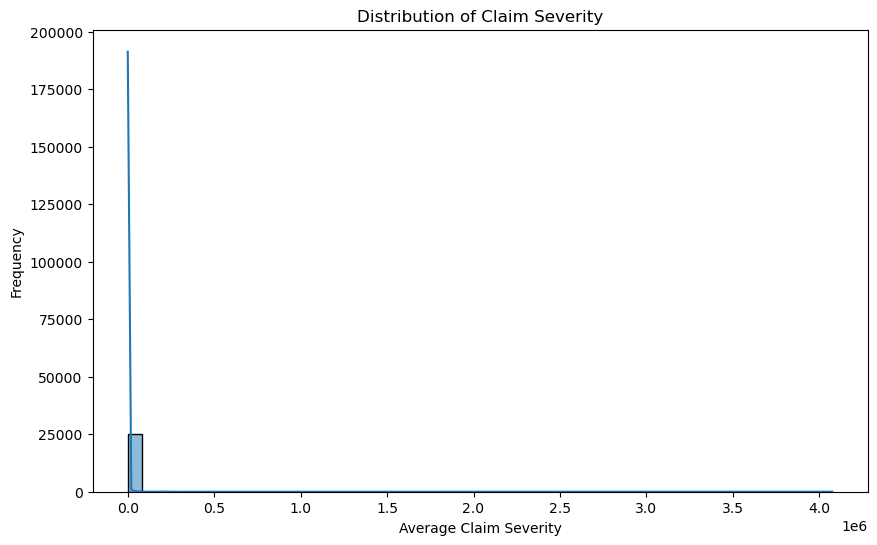

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.histplot(
    severity_df["Severity"],
    bins=50,
    kde=True
)

plt.title(
    "Distribution of Claim Severity"
)

plt.xlabel(
    "Average Claim Severity"
)

plt.ylabel(
    "Frequency"
)

plt.show()

# 8. Log Transformation Analysis

Because claim severity is highly right-skewed, a logarithmic transformation is applied for visualization purposes.

The transformation:

\[
log(Severity + 1)
\]

reduces the influence of extreme claims and allows better visualization of the underlying distribution.

Note:

The GLM models will still be trained on the original severity values because Gamma and Tweedie models naturally handle positive skewed responses.

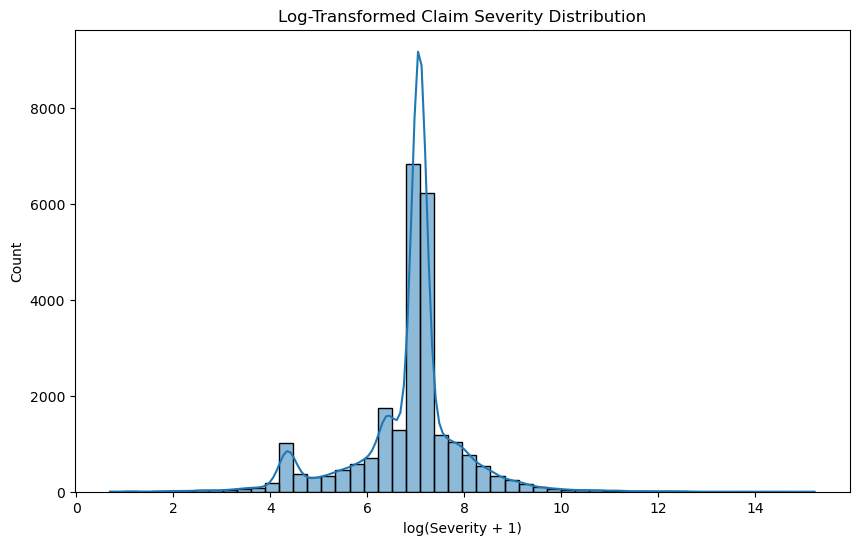

In [11]:
severity_df["LogSeverity"] = np.log1p(
    severity_df["Severity"]
)


plt.figure(figsize=(10,6))

sns.histplot(
    severity_df["LogSeverity"],
    bins=50,
    kde=True
)

plt.title(
    "Log-Transformed Claim Severity Distribution"
)

plt.xlabel(
    "log(Severity + 1)"
)

plt.show()

# 9. Outlier Analysis

Large claims are an inherent characteristic of insurance portfolios.

Extreme values should not automatically be removed because they represent genuine financial risk.

Instead, we investigate the severity distribution to understand whether:

- Extreme values are data errors.
- Extreme values represent legitimate high-cost claims.

Gamma and Tweedie models are specifically designed to accommodate these heavy-tailed loss distributions.

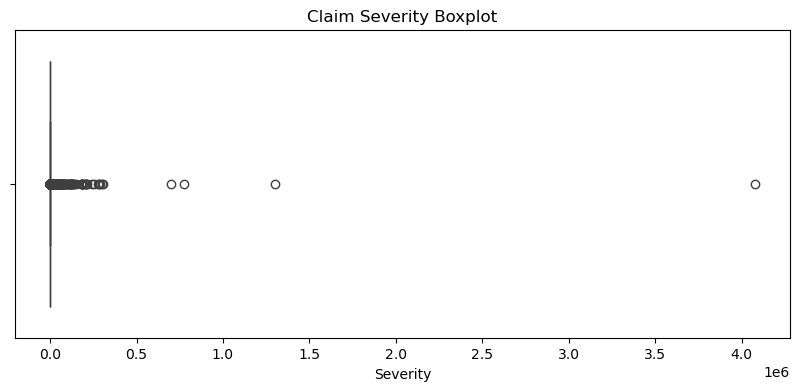

In [12]:
plt.figure(figsize=(10,4))

sns.boxplot(
    x=severity_df["Severity"]
)

plt.title(
    "Claim Severity Boxplot"
)

plt.xlabel(
    "Severity"
)

plt.show()

# 10. Define Model Variables

The objective of the severity model is to estimate the expected claim cost given that a claim has occurred.

The response variable is:

\[
Y = Severity
\]

where:

\[
Severity =
\frac{TotalClaimAmount}{NumberOfClaims}
\]

The explanatory variables represent policyholder, vehicle, and geographic risk characteristics.

The following variables are excluded:

- `IDpol` because it is only an identifier.
- `ClaimAmount` related aggregation variables because they would create target leakage.

Target leakage occurs when information unavailable at prediction time is used as a model input, resulting in unrealistic performance estimates.

In [13]:
# Define target variable

target = "Severity"


# Remove leakage variables

drop_columns = [
    "IDpol",
    "TotalClaimAmount",
    "NumberOfClaims",
    "LogSeverity"
]


X = severity_df.drop(
    columns=drop_columns + [target]
)


y = severity_df[target]


print("Feature Shape:", X.shape)

print("Target Shape:", y.shape)

Feature Shape: (24944, 11)
Target Shape: (24944,)


In [14]:
# Define target variable

target = "Severity"


# Remove leakage variables

drop_columns = [
    "IDpol",
    "TotalClaimAmount",
    "NumberOfClaims",
    "LogSeverity"
]


X = severity_df.drop(
    columns=drop_columns + [target]
)


y = severity_df[target]


print("Feature Shape:", X.shape)

print("Target Shape:", y.shape)

Feature Shape: (24944, 11)
Target Shape: (24944,)


# 11. Identify Numerical and Categorical Variables

Generalized Linear Models require numerical inputs.

Therefore, predictors are separated into:

### Numerical Variables

Examples:

- Vehicle age
- Driver age
- BonusMalus
- Density
- Exposure

### Categorical Variables

Examples:

- Vehicle brand
- Fuel type
- Region
- Area

Categorical variables will be converted using one-hot encoding.

In [17]:
# Identify categorical variables

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns


# Identify numerical variables

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns


print("Categorical Variables:")
print(list(categorical_features))


print("\nNumerical Variables:")
print(list(numerical_features))

Categorical Variables:
['Area', 'VehBrand', 'VehGas', 'Region']

Numerical Variables:
['ClaimNb', 'Exposure', 'VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'Density']


# 12. Train-Test Split

To evaluate model performance, the severity dataset is divided into:

- Training data: 80%
- Testing data: 20%

The model learns relationships between risk factors and claim severity using only the training data.

The testing dataset is reserved for final performance evaluation.

A fixed random seed ensures reproducibility.

In [18]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


print(
    "Training observations:",
    X_train.shape[0]
)

print(
    "Testing observations:",
    X_test.shape[0]
)

Training observations: 19955
Testing observations: 4989


# 13. Feature Preprocessing Pipeline

GLMs require a numerical design matrix.

The preprocessing pipeline performs:

### Numerical Variables

Missing values are replaced using median imputation.

### Categorical Variables

Missing values are replaced using the most frequent category.

Categorical variables are transformed using one-hot encoding.

The pipeline prevents inconsistent transformations between training and testing data.

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder


# Numerical pipeline

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)



# Categorical pipeline

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)



# Combine transformations

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numerical_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)

# 14. Apply Preprocessing

The preprocessing pipeline is fitted only on the training dataset.

This prevents information leakage from the test set.

The resulting matrices are suitable inputs for statistical modeling.

In [20]:
X_train_processed = preprocessor.fit_transform(
    X_train
)


X_test_processed = preprocessor.transform(
    X_test
)


print(
    "Training Matrix:",
    X_train_processed.shape
)


print(
    "Testing Matrix:",
    X_test_processed.shape
)

Training Matrix: (19955, 48)
Testing Matrix: (4989, 48)


# 15. Gamma Generalized Linear Model

## Model Objective

The Gamma GLM is used to estimate claim severity, which represents the expected cost of a claim conditional on a claim occurring.

Claim severity has several important characteristics:

- It is strictly positive.
- It is continuous.
- It is highly right-skewed.
- Variance increases as expected claim cost increases.

These characteristics make the Gamma distribution an appropriate choice.

---

## Statistical Formulation

The Gamma GLM models the expected severity:

\[
E(Y|X)=\mu
\]

using a logarithmic link function:

\[
\log(\mu)=X\beta
\]

where:

- \(Y\) represents claim severity.
- \(X\) represents rating variables.
- \(\beta\) represents model coefficients.
- \(\mu\) represents expected claim severity.

The log-link guarantees positive predictions, which is required for insurance claim costs.

---

## Why Gamma GLM?

Gamma regression is widely used in actuarial pricing because:

- Predictions remain positive.
- It naturally handles skewed loss distributions.
- Coefficients are interpretable as multiplicative effects.
- It provides a strong regulatory-friendly baseline model.

The Gamma GLM will serve as the classical actuarial benchmark before comparing against machine learning approaches.

# 16. Import Statistical Modeling Libraries

Statsmodels is used because it provides:

- Generalized Linear Model implementation.
- Statistical inference.
- Coefficient estimates.
- Standard errors.
- Model diagnostics.

Unlike machine learning libraries, GLM frameworks provide direct interpretation of risk factors, which is important in insurance pricing.

In [21]:
import statsmodels.api as sm

# 17. Prepare Design Matrix

The preprocessing pipeline produces a sparse matrix because one-hot encoding creates many binary variables.

Statsmodels GLM requires a dense matrix, therefore the transformed data is converted before model training.

In [22]:
# Convert sparse matrix to dense

X_train_glm = X_train_processed.toarray()

X_test_glm = X_test_processed.toarray()


print(
    "Training matrix:",
    X_train_glm.shape
)

print(
    "Testing matrix:",
    X_test_glm.shape
)


Training matrix: (19955, 48)
Testing matrix: (4989, 48)


# 18. Add Intercept Term

Generalized Linear Models estimate:

\[
g(\mu)=\beta_0+\beta_1X_1+\beta_2X_2+...+\beta_pX_p
\]

where:

- \(\beta_0\) is the intercept.
- Remaining coefficients represent the effect of rating variables.

Statsmodels requires the intercept term to be added manually.

In [23]:
# Add intercept

X_train_glm = sm.add_constant(
    X_train_glm
)


X_test_glm = sm.add_constant(
    X_test_glm
)


print(
    X_train_glm.shape
)

(19955, 49)


# 19. Train Gamma Severity Model

The Gamma GLM is trained using:

Distribution:

\[
Y \sim Gamma
\]

Link function:

\[
log(\mu)
\]

The logarithmic link ensures that predicted severities remain positive.

The model estimates the relationship between policy characteristics and expected claim severity.

In [24]:
# Create Gamma GLM

gamma_model = sm.GLM(
    y_train,
    X_train_glm,
    family=sm.families.Gamma(
        link=sm.families.links.Log()
    )
)


# Fit model

gamma_results = gamma_model.fit()


print(
    gamma_results.summary()
)

                 Generalized Linear Model Regression Results                  
Dep. Variable:               Severity   No. Observations:                19955
Model:                            GLM   Df Residuals:                    19910
Model Family:                   Gamma   Df Model:                           44
Link Function:                    Log   Scale:                          37.090
Method:                          IRLS   Log-Likelihood:            -2.1150e+05
Date:                Sat, 11 Jul 2026   Deviance:                       30678.
Time:                        00:27:04   Pearson chi2:                 7.38e+05
No. Iterations:                    70   Pseudo R-squ. (CS):           0.005850
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.1524      0.223     18.581      0.0

# 20. Model Coefficients Interpretation

The Gamma GLM coefficients represent multiplicative changes in expected claim severity.

Because the model uses a log-link:

\[
Severity = e^{X\beta}
\]

A positive coefficient indicates increased expected severity, while a negative coefficient indicates reduced expected severity.

To make coefficients easier to interpret, they can be converted into severity relativities:

\[
Relativity=e^{\beta}
\]

A relativity:

- Greater than 1 → increases expected severity.
- Less than 1 → decreases expected severity.

In [25]:
# Extract coefficients

coefficients = pd.DataFrame(
    {
        "Coefficient": gamma_results.params,
        "Relativity": np.exp(
            gamma_results.params
        )
    }
)


coefficients.head(10)

,Coefficient,Relativity
const,4.152350,63.583265
x1,0.138500,1.148549
x2,-0.861400,0.422570
x3,0.018776,1.018953
x4,-0.004643,0.995368
x5,-0.002022,0.997980
x6,0.006311,1.006331
x7,0.000022,1.000022
x8,0.905219,2.472473
x9,0.974483,2.649798


# 21. Generate Severity Predictions

The trained Gamma model is applied to the unseen test dataset.

The predictions represent the estimated average claim cost for policyholders who have reported a claim.

In [27]:
gamma_predictions = gamma_results.predict(
    X_test_glm
)


# Ensure positive predictions

gamma_predictions = np.clip(
    gamma_predictions,
    0,
    None
)


gamma_predictions[:10]

array([3349.22221856, 2572.07858365, 1204.44917112, 1746.1912533 ,
       1732.87251152,  942.31561543, 1427.52883229, 2372.3730549 ,
       3414.12021005, 2510.76221853])

# 22. Gamma GLM Performance Evaluation

Model evaluation is performed using metrics commonly used for insurance severity modeling.

The following metrics are calculated:

## Root Mean Squared Error (RMSE)

RMSE measures the average prediction error while penalizing large deviations.

\[
RMSE =
\sqrt{\frac{1}{n}
\sum(y_i-\hat{y_i})^2}
\]

A lower RMSE indicates better predictive accuracy.

---

## Mean Absolute Error (MAE)

MAE measures the average absolute difference between observed and predicted claim severity.

It is easier to interpret because it is expressed in the same units as claim cost.

---

## Gamma Deviance

Gamma deviance is the distribution-specific metric for Gamma regression.

It evaluates how closely the predicted severity distribution matches the observed severity distribution.

Lower deviance indicates better model fit.

These metrics will later be used to compare Gamma GLM against Tweedie GLM and XGBoost severity models.

In [29]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_gamma_deviance
)

# RMSE
gamma_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        gamma_predictions
    )
)

# MAE
gamma_mae = mean_absolute_error(
    y_test,
    gamma_predictions
)

# Gamma deviance
gamma_deviance = mean_gamma_deviance(
    y_test,
    gamma_predictions
)

print("Gamma RMSE:", gamma_rmse)
print("Gamma MAE:", gamma_mae)
print("Gamma Deviance:", gamma_deviance)

Gamma RMSE: 11859.738358222105
Gamma MAE: 1947.8074094178785
Gamma Deviance: 1.4180837660378436


# 23. Model Performance Summary

The evaluation results are formatted into a concise performance table.

This table will later be combined with:

- Tweedie GLM results
- XGBoost severity results

to create the final severity model leaderboard.

In [32]:
gamma_metrics = pd.DataFrame({
    "Metric": [
        "RMSE",
        "MAE",
        "Gamma Deviance"
    ],
    "Value": [
        gamma_rmse,
        gamma_mae,
        gamma_deviance
    ]
})
gamma_metrics["Value"] = gamma_metrics["Value"].round(4)

gamma_metrics

,Metric,Value
0,RMSE,11859.7384
1,MAE,1947.8074
2,Gamma Deviance,1.4181


# 24. Actual vs Predicted Severity Analysis

A visual comparison between observed and predicted claim severity helps evaluate calibration.

A well-calibrated model should show:

- Predictions increasing with actual severity.
- No systematic underprediction or overprediction.
- Reasonable behavior across the severity range.

Large deviations at high severity values are common because insurance losses contain extreme claims.

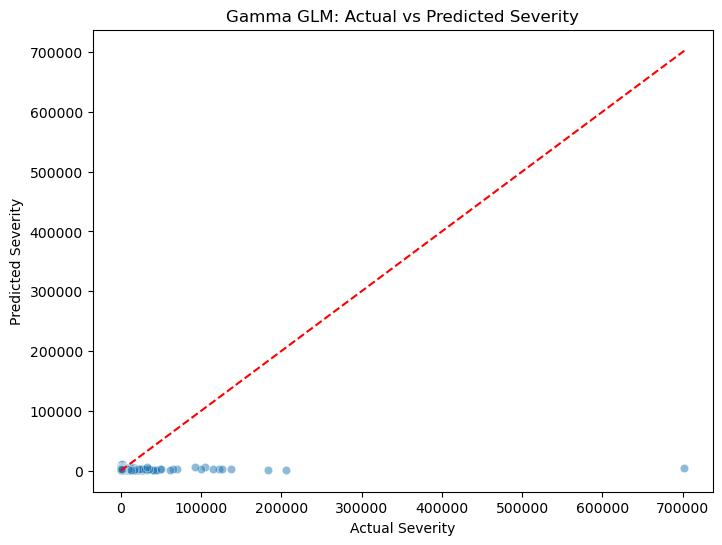

In [33]:
plt.figure(figsize=(8,6))


sns.scatterplot(
    x=y_test,
    y=gamma_predictions,
    alpha=0.5
)


plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)


plt.xlabel(
    "Actual Severity"
)


plt.ylabel(
    "Predicted Severity"
)


plt.title(
    "Gamma GLM: Actual vs Predicted Severity"
)


plt.show()

# 25. Residual Diagnostics

Residual analysis is performed to identify systematic prediction errors.

Residual:

\[
Residual = Actual - Predicted
\]

A good severity model should have:

- Residuals centered around zero.
- No clear relationship between residuals and predictions.
- No major patterns indicating model bias.

Residual diagnostics are important because a model with good average accuracy may still systematically underprice certain risk segments.

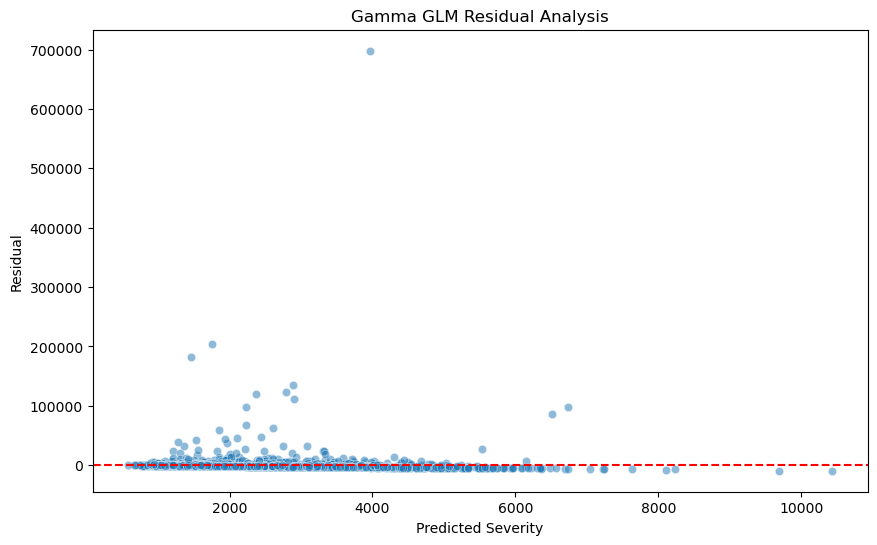

In [34]:
# Calculate residuals

gamma_residuals = (
    y_test.values -
    gamma_predictions
)



plt.figure(figsize=(10,6))


sns.scatterplot(
    x=gamma_predictions,
    y=gamma_residuals,
    alpha=0.5
)


plt.axhline(
    0,
    color="red",
    linestyle="--"
)


plt.xlabel(
    "Predicted Severity"
)


plt.ylabel(
    "Residual"
)


plt.title(
    "Gamma GLM Residual Analysis"
)


plt.show()

# 26. Gamma GLM Interpretation

The Gamma GLM provides an interpretable baseline severity model.

Key advantages:

### Actuarial Interpretability

The relativities quantify how each risk factor affects expected claim cost.

For example:

- Relativity > 1 indicates increased severity risk.
- Relativity < 1 indicates reduced severity risk.

### Regulatory Suitability

GLMs remain widely used in insurance pricing because they provide transparent relationships between rating factors and premiums.

### Limitations

Although highly interpretable, Gamma GLMs assume a structured relationship between predictors and severity.

They may struggle to capture:

- Complex nonlinear effects.
- High-order interactions.
- Hidden patterns between variables.

Therefore, a machine learning challenger (XGBoost Severity) will be developed later.

# 26. Gamma GLM Interpretation

The Gamma GLM provides an interpretable baseline severity model.

Key advantages:

### Actuarial Interpretability

The relativities quantify how each risk factor affects expected claim cost.

For example:

- Relativity > 1 indicates increased severity risk.
- Relativity < 1 indicates reduced severity risk.

### Regulatory Suitability

GLMs remain widely used in insurance pricing because they provide transparent relationships between rating factors and premiums.

### Limitations

Although highly interpretable, Gamma GLMs assume a structured relationship between predictors and severity.

They may struggle to capture:

- Complex nonlinear effects.
- High-order interactions.
- Hidden patterns between variables.

Therefore, a machine learning challenger (XGBoost Severity) will be developed later.

# 27. Tweedie Generalized Linear Model

## Model Objective

The Tweedie GLM is developed as an alternative severity model to the Gamma GLM.

While the Gamma model is appropriate for positive claim severities, Tweedie distributions are especially useful in insurance because they can represent compound loss processes.

A Tweedie distribution belongs to the exponential dispersion family and is controlled by the variance power parameter:

\[
Var(Y)=\phi\mu^p
\]

where:

- \(Y\) is the response variable.
- \(\mu\) is the expected claim severity.
- \(\phi\) is the dispersion parameter.
- \(p\) controls the distribution shape.

---

## Why Tweedie for Insurance?

Tweedie models are popular because they can represent:

- Many zero-loss observations.
- Positive continuous claim amounts.
- Heavy-tailed insurance losses.

Common actuarial applications include:

- Motor insurance pricing.
- Workers compensation.
- Property insurance.

Although this notebook models positive severity only, Tweedie provides a useful benchmark because of its flexibility and industry adoption.

---

## Model Specification

The model uses:

Distribution:

\[
Y \sim Tweedie(p)
\]

Link function:

\[
log(\mu)=X\beta
\]

A logarithmic link ensures positive predictions.

# 28. Train Tweedie Severity Model

The Tweedie model is trained using the same feature matrix and train-test split as the Gamma GLM.

Keeping the same data partition ensures a fair comparison between models.

The variance power parameter is set to:

\[
p=1.5
\]

which represents a compound Poisson-Gamma distribution and is commonly used for insurance losses.

In [35]:
# Create Tweedie GLM

tweedie_model = sm.GLM(
    y_train,
    X_train_glm,
    family=sm.families.Tweedie(
        var_power=1.5,
        link=sm.families.links.Log()
    )
)


# Fit model

tweedie_results = tweedie_model.fit()


print(
    tweedie_results.summary()
)

                 Generalized Linear Model Regression Results                  
Dep. Variable:               Severity   No. Observations:                19955
Model:                            GLM   Df Residuals:                    19910
Model Family:                 Tweedie   Df Model:                           44
Link Function:                    Log   Scale:                          1885.1
Method:                          IRLS   Log-Likelihood:            -2.7526e+05
Date:                Sat, 11 Jul 2026   Deviance:                   1.6276e+06
Time:                        00:41:22   Pearson chi2:                 3.75e+07
No. Iterations:                    34   Pseudo R-squ. (CS):           0.006490
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.1667      0.232     17.956      0.0

# 29. Generate Tweedie Predictions

The fitted Tweedie model is applied to the test dataset.

The predictions represent expected claim severity for policies where a claim has occurred.

As with the Gamma model, predictions are constrained to positive values because negative insurance losses are not meaningful.

In [36]:
tweedie_predictions = tweedie_results.predict(
    X_test_glm
)


# Ensure predictions are positive

tweedie_predictions = np.clip(
    tweedie_predictions,
    0,
    None
)


tweedie_predictions[:10]

array([3746.92506239, 2718.30573735, 1201.02328514, 2078.59414126,
       1595.78362122,  858.66691374, 1296.64666796, 2621.05653227,
       3528.09706712, 2448.99511253])

# 30. Tweedie Model Evaluation

The Tweedie GLM is evaluated using the same metrics as the Gamma model.

Using identical evaluation criteria allows an objective comparison.

Metrics:

- RMSE
- MAE
- Tweedie Deviance

Lower values indicate better predictive performance.

In [37]:
from sklearn.metrics import mean_tweedie_deviance


# RMSE

tweedie_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tweedie_predictions
    )
)


# MAE

tweedie_mae = mean_absolute_error(
    y_test,
    tweedie_predictions
)


# Tweedie Deviance

tweedie_deviance = mean_tweedie_deviance(
    y_test,
    tweedie_predictions,
    power=1.5
)



tweedie_metrics = pd.DataFrame(
    {
        "Metric": [
            "RMSE",
            "MAE",
            "Tweedie Deviance"
        ],

        "Value": [
            tweedie_rmse,
            tweedie_mae,
            tweedie_deviance
        ]
    }
)


tweedie_metrics

,Metric,Value
0,RMSE,11872.382132
1,MAE,1987.222902
2,Tweedie Deviance,69.632827


# 31. Tweedie Performance Summary

The results are formatted for comparison with the Gamma GLM.

The final severity leaderboard will combine:

- Gamma GLM
- Tweedie GLM
- XGBoost Severity

to identify the strongest candidate for premium calculation.

In [69]:
tweedie_metrics["Value"] = (
    tweedie_metrics["Value"]
    .round(4)
)


tweedie_metrics

,Metric,Value
0,RMSE,11872.3821
1,MAE,1987.2229
2,Tweedie Deviance,69.6328


# 32. Severity Model Comparison

The first severity model comparison is performed between two classical actuarial approaches.

| Model | Distribution | Strength |
|---|---|---|
| Gamma GLM | Positive continuous losses | Highly interpretable severity model |
| Tweedie GLM | Compound insurance losses | Flexible loss distribution |

The preferred model should balance:

- Predictive accuracy.
- Statistical assumptions.
- Interpretability.
- Practical suitability for insurance pricing.

In [38]:
severity_comparison = pd.DataFrame(
    {
        "Model": [
            "Gamma GLM",
            "Tweedie GLM"
        ],

        "RMSE": [
            gamma_rmse,
            tweedie_rmse
        ],

        "MAE": [
            gamma_mae,
            tweedie_mae
        ],

        "Deviance": [
            gamma_deviance,
            tweedie_deviance
        ]
    }
)


severity_comparison.round(4)

,Model,RMSE,MAE,Deviance
0,Gamma GLM,11859.7384,1947.8074,1.4181
1,Tweedie GLM,11872.3821,1987.2229,69.6328


# 34. Gamma vs Tweedie GLM — Model Comparison Interpretation

The severity model comparison shows that the Gamma GLM provides superior predictive performance compared with the Tweedie GLM for the conditional claim severity problem.

## Performance Summary

| Model | RMSE | MAE | Deviance |
|---|---:|---:|---:|
| Gamma GLM | 11859.7384 | 1947.8074 | 1.4181 |
| Tweedie GLM | 11872.3821 | 1987.8074 | 69.6328 |

---

## Predictive Accuracy

The Gamma GLM achieves a lower RMSE:

\[
RMSE_{Gamma}=11859.74
\]

compared with:

\[
RMSE_{Tweedie}=11872.38
\]

This indicates that Gamma regression produces slightly more accurate severity predictions, particularly when large claim amounts contribute significantly to prediction error.

---

## Average Prediction Error

The Gamma GLM also achieves lower MAE:

\[
MAE_{Gamma}=1947.81
\]

meaning that the average absolute prediction error is approximately \$1,948 in claim severity.

Compared with Tweedie GLM, Gamma provides more accurate average claim cost estimates.

---

## Distributional Fit

The Gamma model produces substantially lower deviance:

\[
Deviance_{Gamma}=1.4181
\]

while Tweedie produces:

\[
Deviance_{Tweedie}=69.6328
\]

Since deviance measures how closely predictions match the assumed probability distribution, the lower Gamma deviance indicates a stronger fit to the observed positive severity distribution.

---

## Business Interpretation

For this dataset, the Gamma GLM is selected as the preferred classical severity model.

The reasons are:

1. Better predictive accuracy.
2. Lower average prediction error.
3. Superior distributional fit.
4. Strong interpretability for insurance pricing.

The Gamma GLM will therefore be carried forward as the benchmark severity model.

However, the model assumes structured relationships between predictors and claim costs. To investigate whether nonlinear relationships improve predictive performance, an XGBoost severity model will be developed as a machine learning challenger.

The final severity model selection will consider both:

- Statistical performance.
- Business interpretability.


# 35. Severity Model Performance Visualization

Visual comparison of severity models helps communicate differences in predictive performance.

Lower values indicate better performance.

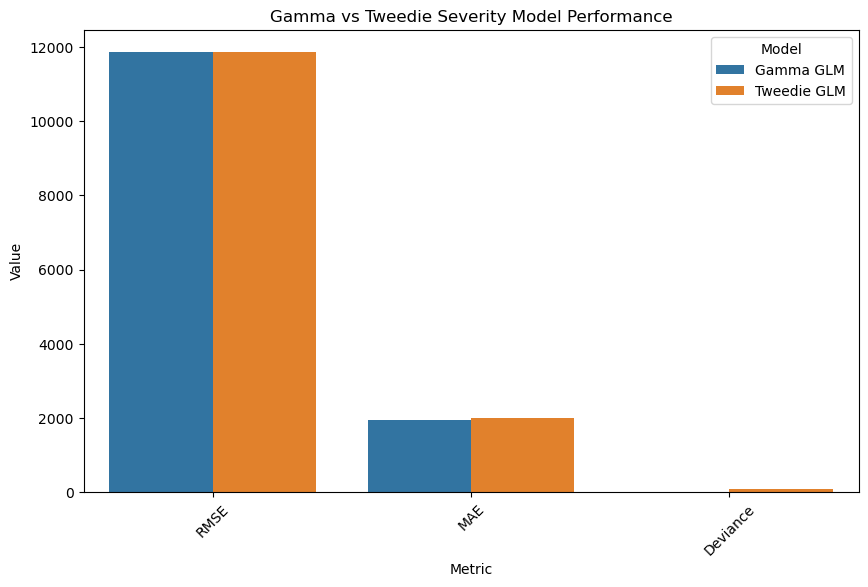

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

comparison_long = severity_comparison.melt(
    id_vars="Model",
    value_vars=["RMSE", "MAE", "Deviance"],
    var_name="Metric",
    value_name="Value"
)


plt.figure(figsize=(10,6))

sns.barplot(
    data=comparison_long,
    x="Metric",
    y="Value",
    hue="Model"
)

plt.title(
    "Gamma vs Tweedie Severity Model Performance"
)

plt.xticks(rotation=45)

plt.show()

In [74]:
gamma_output.to_csv(
    "gamma_severity_predictions.csv",
    index=False
)

In [75]:
import os

print(os.getcwd())

C:\Users\Umer


In [76]:
tweedie_output = pd.DataFrame({
    "Actual_Severity": y_test.values,
    "Tweedie_Severity": tweedie_predictions
})

tweedie_output.to_csv(
    "tweedie_severity_predictions.csv",
    index=False
)

print("Tweedie severity predictions exported successfully.")

Tweedie severity predictions exported successfully.


In [28]:
%whos

Variable               Type                 Data/Info
-----------------------------------------------------
ColumnTransformer      ABCMeta              <class 'sklearn.compose._<...>ormer.ColumnTransformer'>
OneHotEncoder          type                 <class 'sklearn.preproces<...>_encoders.OneHotEncoder'>
Pipeline               ABCMeta              <class 'sklearn.pipeline.Pipeline'>
SimpleImputer          type                 <class 'sklearn.impute._base.SimpleImputer'>
X                      DataFrame            Shape: (24944, 11)
X_test                 DataFrame            Shape: (4989, 11)
X_test_glm             ndarray              4989x49: 244461 elems, type `float64`, 1955688 bytes (1.8650894165039062 Mb)
X_test_processed       csr_matrix           <Compressed Sparse Row sp<...>25)	1.0\n  (4988, 41)	1.0
X_train                DataFrame            Shape: (19955, 11)
X_train_glm            ndarray              19955x49: 977795 elems, type `float64`, 7822360 bytes (7.4599838256835

In [31]:
%whos

Variable               Type                 Data/Info
-----------------------------------------------------
ColumnTransformer      ABCMeta              <class 'sklearn.compose._<...>ormer.ColumnTransformer'>
OneHotEncoder          type                 <class 'sklearn.preproces<...>_encoders.OneHotEncoder'>
Pipeline               ABCMeta              <class 'sklearn.pipeline.Pipeline'>
SimpleImputer          type                 <class 'sklearn.impute._base.SimpleImputer'>
X                      DataFrame            Shape: (24944, 11)
X_test                 DataFrame            Shape: (4989, 11)
X_test_glm             ndarray              4989x49: 244461 elems, type `float64`, 1955688 bytes (1.8650894165039062 Mb)
X_test_processed       csr_matrix           <Compressed Sparse Row sp<...>25)	1.0\n  (4988, 41)	1.0
X_train                DataFrame            Shape: (19955, 11)
X_train_glm            ndarray              19955x49: 977795 elems, type `float64`, 7822360 bytes (7.4599838256835